# 🏠 Victorian Housing Data Pipeline
**Sources:** Valuer-General Victoria · DFFH Rental Report · ABS Building Approvals · RBA Lending Rates · ASX Announcements  
**Output:** SQLite database + CSV exports + Excel dashboard with gross yield by suburb

---


## 0 · Setup — install dependencies & add package to path

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
    "requests", "openpyxl", "pandas", "xlrd", "beautifulsoup4", "lxml",
    "--quiet"])

# Make sure the package is importable wherever the notebook lives
import sys, pathlib
HERE = pathlib.Path().resolve()
# Walk up until we find the vic_housing package folder
for parent in [HERE, *HERE.parents]:
    if (parent / "vic_housing" / "__init__.py").exists():
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        print(f"Package found at: {parent}")
        break
else:
    print("⚠️  Could not auto-locate vic_housing package.")
    print("   Set PKG_DIR below to the folder that contains vic_housing/")
    # PKG_DIR = r"C:/path/to/vic_housing_pipeline/vic_housing"
    # sys.path.insert(0, PKG_DIR)


Package found at: C:\Users\henry\Desktop\career\Resumes\github\vic-housing-data\vic_housing_pipeline\vic_housing


## 1 · Initialise the database

In [2]:
from vic_housing.core import init_db, DB_PATH
init_db()
print(f"Database: {DB_PATH}")


2026-06-07 12:31:19 [INFO] vic_housing.core: Database ready: C:\Users\henry\Desktop\career\Resumes\github\vic-housing-data\vic_housing_pipeline\vic_housing\vic_housing.db


Database: C:\Users\henry\Desktop\career\Resumes\github\vic-housing-data\vic_housing_pipeline\vic_housing\vic_housing.db


## 2 · Connector: Valuer-General Victoria (VGV)
Fetches median **sale prices** by suburb & LGA from data.vic.gov.au (quarterly XLSX releases).


In [3]:
from vic_housing import vgv
new_rows = vgv.run()
print(f"New rows inserted: {new_rows:,}")


C:\Users\henry\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2026-06-07 12:31:20 [INFO] vic_housing.vgv: CKAN search: 'Victorian Property Sales Report median house suburb quarterly'
2026-06-07 12:31:20 [INFO] vic_housing.vgv:   Package: Victorian Property Sales Report - Median House by Suburb Quarterly -- 6 resources
2026-06-07 12:31:20 [INFO] vic_housing.vgv:   Fetching: December 2023 Quarter
2026-06-07 12:31:22 [INFO] vic_housing.vgv:     -> 3699 rows
2026-06-07 12:31:23 [INFO] vic_housing.vgv:   Fetching: March 2024 Quarter
2026-06-07 12:32:20 [WARNING] vic_housing.vgv:   Could not retrieve: /__data/assets/excel_doc/0021/716052/Median-House-VGS-1st-Qtr-2024.xls
2026-06-07 12:32:20 [INFO] vic_housing.vgv:   Fetching: June 2024 Quarter
2026-06-07 12:32:36 [INFO] vic_housing.vgv:     -> 3679 rows
2026-06-07 12:32:36 [INFO] vic_housing.v

New rows inserted: 6


In [4]:
import pandas as pd
from vic_housing.core import get_conn

conn = get_conn()
df_sales = pd.read_sql_query(
    "SELECT * FROM sales_medians ORDER BY period DESC, median_price DESC LIMIT 50",
    conn)
conn.close()
print(f"Total rows in sales_medians: {len(df_sales)}")
df_sales.head(20)


Total rows in sales_medians: 50


,id,period,lga,suburb,dwelling_type,median_price,num_sales,source,fetched_at
0,323240,2025-Q2,,TOORAK,house,5000000.0,None,VGV,2026-06-07 02:18:09
1,320380,2025-Q2,,BRIGHTON,house,3550000.0,None,VGV,2026-06-07 02:18:09
2,320505,2025-Q2,,CANTERBURY,house,3544000.0,None,VGV,2026-06-07 02:18:09
3,320920,2025-Q2,,DEEPDENE,house,3450000.0,None,VGV,2026-06-07 02:18:09
4,322155,2025-Q2,,MONT ALBERT,house,3210000.0,None,VGV,2026-06-07 02:18:09
5,320135,2025-Q2,,BALWYN,house,3128000.0,None,VGV,2026-06-07 02:18:09
6,322610,2025-Q2,,PORTSEA,house,2825000.0,None,VGV,2026-06-07 02:18:09
7,321705,2025-Q2,,KEW,house,2810500.0,None,VGV,2026-06-07 02:18:09
8,321595,2025-Q2,,IVANHOE EAST,house,2732500.0,None,VGV,2026-06-07 02:18:09
9,321320,2025-Q2,,GLEN IRIS,house,2715000.0,None,VGV,2026-06-07 02:18:09


## 3 · Connector: DFFH Rental Report (RTBA)
Fetches median **weekly rents** by suburb & LGA from the Residential Tenancies Bond Authority bond data.


In [5]:
from vic_housing import rental
new_rows = rental.run()
print(f"New rows inserted: {new_rows:,}")


2026-06-07 12:43:00 [INFO] vic_housing.rental: Locating latest DFFH rental Excel file...
2026-06-07 12:43:00 [INFO] vic_housing.rental:   Latest suburb file link: https://www.dffh.vic.gov.au/moving-annual-rent-suburb-september-quarter-2025-excel
2026-06-07 12:43:00 [INFO] vic_housing.rental:   Downloading: https://www.dffh.vic.gov.au/moving-annual-rent-suburb-september-quarter-2025-excel
2026-06-07 12:43:01 [INFO] vic_housing.rental:   Downloaded 1,135,709 bytes from %20suburb%20and%20town%20-%20September%20quarter%202025.xlsx
2026-06-07 12:43:03 [INFO] vic_housing.rental:   Sheets: ['1 bedroom flat', '2 bedroom flat', '3 bedroom flat', '2 bedroom house', '3 bedroom house', '4 bedroom house', 'All properties']
2026-06-07 12:43:03 [INFO] vic_housing.rental:     Sheet '1 bedroom flat' (1br): 15,138 rows
2026-06-07 12:43:03 [INFO] vic_housing.rental:     Sheet '2 bedroom flat' (2br): 16,236 rows
2026-06-07 12:43:04 [INFO] vic_housing.rental:     Sheet '3 bedroom flat' (3br): 15,591 rows
2

New rows inserted: 0


In [6]:
conn = get_conn()
df_rental = pd.read_sql_query(
    "SELECT * FROM rental_medians ORDER BY period DESC, median_rent DESC LIMIT 50",
    conn)
conn.close()
print(f"Total rows in rental_medians: {len(df_rental)}")
df_rental.head(20)


Total rows in rental_medians: 50


,id,period,lga,suburb,dwelling_type,median_rent,source,fetched_at
0,80388,2025-Q3,Inner Melbourne,Toorak,4br,1875.0,DFFH,2026-06-06 23:10:17
1,78927,2025-Q3,Inner Melbourne,Armadale,4br,1738.0,DFFH,2026-06-06 23:10:17
2,80207,2025-Q3,Inner Melbourne,South Yarra,4br,1700.0,DFFH,2026-06-06 23:10:17
3,82654,2025-Q3,Southern Melbourne,Brighton,4br,1650.0,DFFH,2026-06-06 23:10:17
4,79419,2025-Q3,Inner Melbourne,Elwood,4br,1500.0,DFFH,2026-06-06 23:10:17
5,81830,2025-Q3,Inner Eastern Melbourne,Hawthorn,4br,1500.0,DFFH,2026-06-06 23:10:17
6,83367,2025-Q3,Southern Melbourne,Malvern,4br,1400.0,DFFH,2026-06-06 23:10:17
7,78831,2025-Q3,Inner Melbourne,Albert Park-Middle Park-West St Kilda,4br,1400.0,DFFH,2026-06-06 23:10:17
8,79987,2025-Q3,Inner Melbourne,Prahran-Windsor,4br,1350.0,DFFH,2026-06-06 23:10:17
9,80090,2025-Q3,Inner Melbourne,Richmond-Burnley,4br,1315.0,DFFH,2026-06-06 23:10:17


## 4 · Connector: ABS Building Approvals (8731.0)
Monthly dwelling approvals by region and type. Uses the ABS SDMX Data API with an XLSX fallback.


In [7]:
from vic_housing import abs as abs_mod
new_rows = abs_mod.run()
print(f"New rows inserted: {new_rows:,}")


2026-06-07 12:43:05 [INFO] vic_housing.abs: Fetching ABS BA_GCCSA: https://data.api.abs.gov.au/rest/data/ABS,BA_GCCSA,1.0.0/all
2026-06-07 12:43:20 [INFO] vic_housing.abs:   SDMX: 7749 observations parsed
2026-06-07 12:43:20 [INFO] vic_housing.abs: ABS: 7749 rows -> 0 new inserted


New rows inserted: 0


In [8]:
conn = get_conn()
df_abs = pd.read_sql_query(
    "SELECT * FROM building_approvals ORDER BY period DESC LIMIT 50",
    conn)
conn.close()
df_abs.head(20)


,id,period,region,dwelling_type,seasonality,num_approvals,value_000,source,fetched_at
0,5646,2026-04,Western Australia,unit,original,0,None,ABS,2026-06-06 22:45:37
1,18576,2026-04,Western Australia,transport buildings,original,0,None,ABS,2026-06-06 22:45:37
2,13462,2026-04,Western Australia,total,original,71,None,ABS,2026-06-06 22:45:37
3,86008,2026-04,Western Australia,short term accommoda,original,0,None,ABS,2026-06-06 22:45:38
4,39884,2026-04,Western Australia,retail and wholesale,original,0,None,ABS,2026-06-06 22:45:37
5,9554,2026-04,Western Australia,religion buildings,original,0,None,ABS,2026-06-06 22:45:37
6,31542,2026-04,Western Australia,offices,original,0,None,ABS,2026-06-06 22:45:37
7,9146,2026-04,Western Australia,house,original,0,None,ABS,2026-06-06 22:45:37
8,142006,2026-04,Western Australia,health buildings,original,44316,None,ABS,2026-06-06 22:45:39
9,30608,2026-04,Western Australia,entertainment and re,original,0,None,ABS,2026-06-06 22:45:37


## 5 · Connector: RBA Lending Rates (F5 / F6 / F7)
Monthly lending rates — owner-occupier vs investor, P&I vs IO. Direct from RBA statistical tables CSV.


In [9]:
from vic_housing import rba
new_rows = rba.run()
print(f"New rows inserted: {new_rows:,}")


2026-06-07 12:43:20 [INFO] vic_housing.rba: Fetching RBA F5: Indicator Lending Rates
2026-06-07 12:43:22 [INFO] vic_housing.rba:   F5: 7776 observations
2026-06-07 12:43:22 [INFO] vic_housing.rba: Fetching RBA F6: Housing Lending Rates (OO vs Investor / P&I vs IO)
2026-06-07 12:43:25 [INFO] vic_housing.rba:   F6: 3444 observations
2026-06-07 12:43:25 [INFO] vic_housing.rba: Skipping F7 (Business Lending Rates (by firm size)) -- set RBA_INCLUDE_F7=true to enable
2026-06-07 12:43:25 [INFO] vic_housing.rba: RBA: 11220 rows -> 0 new inserted


New rows inserted: 0


In [10]:
conn = get_conn()
df_rba = pd.read_sql_query(
    """SELECT period, series_id, series_label, rate_pct
       FROM lending_rates
       WHERE series_id LIKE '%FILRHL%'
          OR series_id LIKE 'F6/%'
       ORDER BY period ASC, series_id""",
    conn)
conn.close()
print(f"RBA housing lending rate observations: {len(df_rba):,}")
df_rba.tail(20)


RBA housing lending rate observations: 6,155


,period,series_id,series_label,rate_pct
6135,2026-04,F6/FLRHOLB,Lending rates; Housing credit; New loans funde...,6.09
6136,2026-04,F6/FLRHOOFA,Lending rates; Housing credit; Outstanding; Ow...,5.47
6137,2026-04,F6/FLRHOOFB,Lending rates; Housing credit; Outstanding; Ow...,6.06
6138,2026-04,F6/FLRHOOI,Lending rates; Housing credit; Outstanding; Ow...,6.59
6139,2026-04,F6/FLRHOOP,Lending rates; Housing credit; Outstanding; Ow...,5.95
6140,2026-04,F6/FLRHOOTA,Lending rates; Housing credit; Outstanding; Ow...,5.98
6141,2026-04,F6/FLRHOOTL,Lending rates; Housing credit; Outstanding; Ow...,5.98
6142,2026-04,F6/FLRHOOVA,Lending rates; Housing credit; Outstanding; Ow...,6.00
6143,2026-04,F6/FLRHOOVL,Lending rates; Housing credit; Outstanding; Ow...,6.00
6144,2026-04,F6/FLRHOVA,Lending rates; Housing credit; New loans funde...,5.95


## 6 · Connector: ASX Property Announcements
Recent ASX filings for MGR, SGP, LLC, DHG, GMG, REA, VCX, CQR, CLW, HMC.


In [11]:
from vic_housing import asx
new_rows = asx.run()
print(f"New rows inserted: {new_rows:,}")


2026-06-07 12:43:27 [INFO] vic_housing.asx:   MGR: 5 announcements (MarkitDigital)
2026-06-07 12:43:28 [INFO] vic_housing.asx:   SGP: 5 announcements (MarkitDigital)
2026-06-07 12:43:30 [INFO] vic_housing.asx:   LLC: 5 announcements (MarkitDigital)
2026-06-07 12:43:31 [INFO] vic_housing.asx:   GMG: 5 announcements (MarkitDigital)
2026-06-07 12:43:33 [INFO] vic_housing.asx:   REA: 5 announcements (MarkitDigital)
2026-06-07 12:43:34 [INFO] vic_housing.asx:   VCX: 5 announcements (MarkitDigital)
2026-06-07 12:43:36 [INFO] vic_housing.asx:   CQR: 5 announcements (MarkitDigital)
2026-06-07 12:43:37 [INFO] vic_housing.asx:   CLW: 5 announcements (MarkitDigital)
2026-06-07 12:43:39 [INFO] vic_housing.asx:   HMC: 5 announcements (MarkitDigital)
2026-06-07 12:43:40 [WARNING] vic_housing.asx:   APD: MarkitDigital error: 400 Client Error: Bad Request for url: https://asx.api.markitdigital.com/asx-research/1.0/companies/APD/announcements?count=20
2026-06-07 12:43:40 [WARNING] vic_housing.asx:   AP

New rows inserted: 0


In [12]:
conn = get_conn()
df_asx = pd.read_sql_query(
    """SELECT ticker, announced_at, headline
       FROM asx_announcements
       ORDER BY announced_at DESC
       LIMIT 40""",
    conn)
conn.close()
df_asx.head(20)


,ticker,announced_at,headline
0,DXS,2026-06-05,Update on APAC matter and review of infrastruc...
1,LLC,2026-06-05,Change in substantial holding
2,REA,2026-06-04,Update - Notification of buy-back - REA
3,GMG,2026-06-03,Appendix 3Y
4,REA,2026-06-03,Update - Notification of buy-back - REA
5,REA,2026-06-02,Update - Notification of buy-back - REA
6,LLC,2026-06-01,Change in substantial holding
7,MGR,2026-06-01,Appendix 3X - Janelle Hopkins
8,REA,2026-06-01,Update - Notification of buy-back - REA
9,LLC,2026-05-31,Lendlease announces sale of MSG North


## 7 · Analysis: Gross Rental Yield by Suburb
Joins sale prices (VGV) to weekly rents (DFFH) to compute:

$$\text{Gross Yield} = \frac{\text{Median Weekly Rent} \times 52}{\text{Median Sale Price}} \times 100$$


In [13]:
conn = get_conn()
df_s = pd.read_sql_query(
    "SELECT period, suburb, median_price FROM sales_medians WHERE dwelling_type='house'",
    conn)
df_r = pd.read_sql_query(
    "SELECT period, suburb, median_rent FROM rental_medians WHERE dwelling_type='all'",
    conn)
conn.close()

# Normalise suburb case
df_s["suburb"] = df_s["suburb"].str.upper().str.strip()
df_r["suburb"] = df_r["suburb"].str.upper().str.strip()
df_s["median_price"] = pd.to_numeric(df_s["median_price"], errors="coerce")
df_r["median_rent"]  = pd.to_numeric(df_r["median_rent"],  errors="coerce")

# Extract year from period — handles "2023" (annual) and "2024-Q3" (quarterly)
df_s["year"] = df_s["period"].str[:4]
df_r["year"] = df_r["period"].str[:4]

# Aggregate to one price/rent per suburb-year (median across quarters if multiple)
price_yr = df_s.groupby(["year", "suburb"])["median_price"].median().reset_index()
rent_yr  = df_r.groupby(["year", "suburb"])["median_rent"].median().reset_index()

# Join on year + suburb
df_yields = price_yr.merge(rent_yr, on=["year", "suburb"], how="inner")
df_yields = df_yields.dropna(subset=["median_price", "median_rent"])
df_yields = df_yields[df_yields["median_price"] > 0]
df_yields["gross_yield_pct"] = (
    df_yields["median_rent"] * 52 / df_yields["median_price"] * 100
).round(2)
df_yields = df_yields.sort_values(["year", "gross_yield_pct"], ascending=[False, False])

print(f"Suburbs with yield data: {len(df_yields):,}")
print(f"Years covered:           {sorted(df_yields['year'].unique())}")
df_yields[["year", "suburb", "median_price", "median_rent", "gross_yield_pct"]].head(30)


Suburbs with yield data: 1,027
Years covered:           ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


,year,suburb,median_price,median_rent,gross_yield_pct
1010,2025,SOUTHBANK,572400.0,675.0,6.13
973,2025,DOCKLANDS,610000.0,700.0,5.97
993,2025,MORWELL,353000.0,380.0,5.60
950,2025,BAIRNSDALE,440000.0,460.0,5.44
1001,2025,PORTLAND,421250.0,415.0,5.12
953,2025,BENALLA,461250.0,443.0,4.99
985,2025,HORSHAM,396300.0,380.0,4.99
1007,2025,SHEPPARTON,473250.0,450.0,4.94
991,2025,MELTON,500000.0,450.0,4.68
992,2025,MILDURA,501750.0,450.0,4.66


### Yield distribution — top vs bottom suburbs

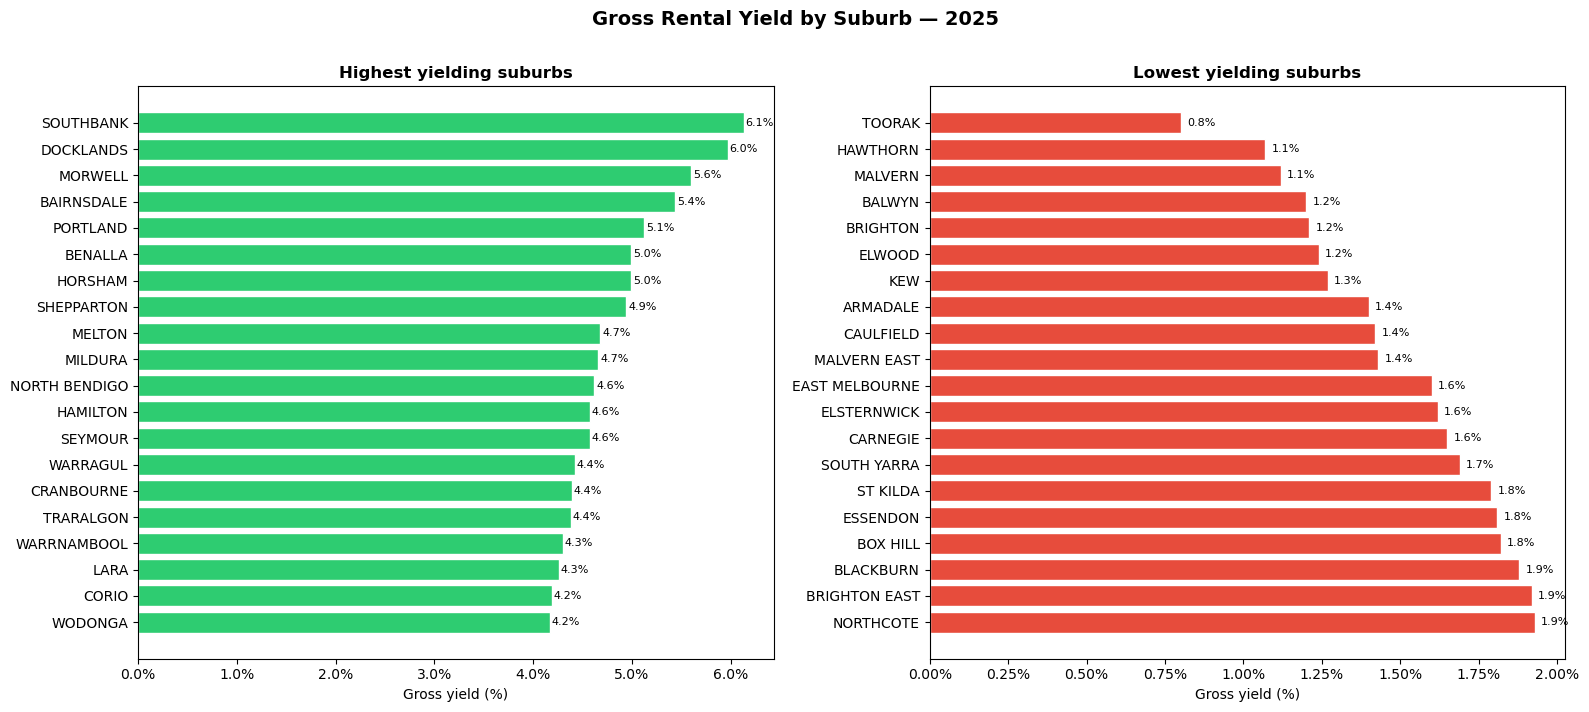

Chart saved -> exports/yield_by_suburb.png  (1,027 suburb-year records, 13 years)


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

if len(df_yields) > 0:
    latest_year = df_yields["year"].max()
    latest = df_yields[df_yields["year"] == latest_year].copy()
    top20  = latest.nlargest(20, "gross_yield_pct")
    bot20  = latest.nsmallest(20, "gross_yield_pct")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Gross Rental Yield by Suburb — {latest_year}",
                 fontsize=14, fontweight="bold", y=1.01)

    for ax, df_plot, title, colour in [
        (axes[0], top20, "Highest yielding suburbs", "#2ecc71"),
        (axes[1], bot20, "Lowest yielding suburbs",  "#e74c3c"),
    ]:
        bars = ax.barh(df_plot["suburb"],
                       df_plot["gross_yield_pct"], color=colour, edgecolor="white")
        ax.set_xlabel("Gross yield (%)")
        ax.set_title(title, fontweight="bold")
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        ax.invert_yaxis()
        for bar in bars:
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.1f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig("exports/yield_by_suburb.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved -> exports/yield_by_suburb.png  ({len(df_yields):,} suburb-year records, {df_yields['year'].nunique()} years)")
else:
    print("No joined yield data yet — run both VGV and rental connectors first.")


### RBA lending rates over time

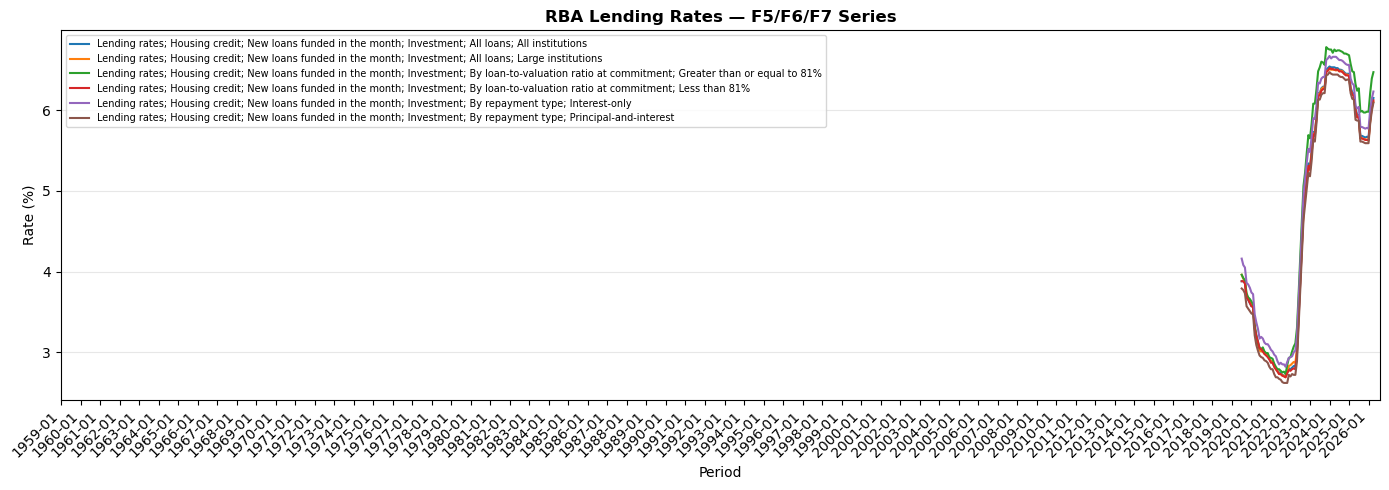

Chart saved → exports/rba_rates.png


In [18]:
if len(df_rba) > 0:
    pivot = df_rba.pivot_table(index="period", columns="series_label",
                                values="rate_pct", aggfunc="mean")
    pivot = pivot.sort_index()

    fig, ax = plt.subplots(figsize=(14, 5))
    for col in pivot.columns[:6]:   # show up to 6 series
        ax.plot(pivot.index, pivot[col], linewidth=1.5, label=col)

    ax.set_title("RBA Lending Rates — F5/F6/F7 Series", fontweight="bold")
    ax.set_ylabel("Rate (%)")
    ax.set_xlabel("Period")
    ax.legend(fontsize=7, loc="upper left")
    # Show every 12th label to avoid crowding
    ticks = pivot.index.tolist()
    ax.set_xticks(ticks[::12])
    ax.set_xticklabels(ticks[::12], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("exports/rba_rates.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved → exports/rba_rates.png")
else:
    print("No RBA data yet.")


## 8 · Export — CSV + Excel dashboard
Writes one CSV per table and a multi-sheet Excel workbook with the derived **Yields_Calc** sheet.


In [19]:
from vic_housing import exports
exports.run()

import os
out = "exports"
print("\nFiles in exports/:")
for f in sorted(os.listdir(out)):
    size = os.path.getsize(os.path.join(out, f))
    print(f"  {f:<45} {size/1024:.1f} KB")


2026-06-07 13:47:39 [INFO] vic_housing.exports: Exporting CSVs...
2026-06-07 13:47:39 [INFO] vic_housing.exports:   CSV: sales_medians.csv (17616 rows)
2026-06-07 13:47:40 [INFO] vic_housing.exports:   CSV: rental_medians.csv (111825 rows)
2026-06-07 13:47:40 [INFO] vic_housing.exports:   CSV: building_approvals.csv (59396 rows)
2026-06-07 13:47:40 [INFO] vic_housing.exports:   CSV: lending_rates.csv (11220 rows)
2026-06-07 13:47:40 [INFO] vic_housing.exports:   CSV: asx_announcements.csv (48 rows)
2026-06-07 13:47:40 [INFO] vic_housing.exports: Building Excel dashboard...
2026-06-07 13:47:43 [INFO] vic_housing.exports:   Sheet 'Sales_Medians': 17616 rows
2026-06-07 13:47:54 [INFO] vic_housing.exports:   Sheet 'Rental_Medians': 111825 rows
2026-06-07 13:47:59 [INFO] vic_housing.exports:   Sheet 'Building_Approvl': 59396 rows
2026-06-07 13:48:00 [INFO] vic_housing.exports:   Sheet 'Lending_Rates': 11220 rows
2026-06-07 13:48:00 [INFO] vic_housing.exports:   Sheet 'ASX_Announcemnts': 48 


Files in exports/:
  .gitkeep                                      0.0 KB
  analysis                                      4.0 KB
  asx_announcements.csv                         3.8 KB
  building_approvals.csv                        4836.9 KB
  lending_rates.csv                             1495.5 KB
  rba_rates.png                                 131.2 KB
  rental_medians.csv                            9506.4 KB
  sales_medians.csv                             1138.3 KB
  vic_housing_dashboard.xlsx                    7145.5 KB
  yield_by_suburb.png                           160.9 KB


---
## ✅ Done

| File | What it is |
|------|-----------|
| `vic_housing.db` | SQLite database — query directly with DB Browser or pandas |
| `exports/*.csv` | One CSV per table |
| `exports/vic_housing_dashboard.xlsx` | Multi-sheet Excel with Yields_Calc tab |
| `exports/yield_by_suburb.png` | Yield bar chart |
| `exports/rba_rates.png` | RBA rates time series |

**Re-run at any time** — all connectors are idempotent (no duplicate rows).


## 9 · Interstate & policy-rate data (free connectors)

Two free feeds that close the gaps in the analysis — both now permanent, idempotent pipeline connectors:

- **`cashrate`** — RBA Cash Rate Target (F1.1), monthly 1990–present. The actual policy instrument (lending rates in §5 are downstream of it).
- **`capitals`** — ABS `RES_DWELL` median established-house & unit prices for **every capital city**, quarterly 2016–present. This is the **interstate counterfactual** that lets us run a difference-in-differences on Victoria-specific policy.


In [20]:
from vic_housing import cashrate, capitals
print("Cash rate :", f"{cashrate.run():,} new rows")
print("Capitals  :", f"{capitals.run():,} new rows")

conn = get_conn()
cap_latest = pd.read_sql_query(
    """SELECT region AS city, value AS median_house_000s
       FROM capital_prices
       WHERE measure='median_house'
         AND period = (SELECT MAX(period) FROM capital_prices WHERE measure='median_house')
         AND region LIKE 'Greater%'
       ORDER BY value DESC""", conn)
conn.close()
print("\nLatest median established-house price by capital ($000s):")
cap_latest


2026-06-07 13:48:19 [INFO] vic_housing.cashrate: Fetching RBA Cash Rate Target (F1.1)
2026-06-07 13:48:19 [INFO] vic_housing.cashrate: Cash rate: 430 months parsed -> 0 new inserted
2026-06-07 13:48:19 [INFO] vic_housing.capitals: Fetching ABS RES_DWELL (interstate capital-city dwelling prices)
2026-06-07 13:48:19 [INFO] vic_housing.capitals: Capitals: 3600 rows parsed -> 0 new inserted


Cash rate : 0 new rows
Capitals  : 0 new rows

Latest median established-house price by capital ($000s):


,city,median_house_000s
0,Greater Sydney,1515.0
1,Greater Brisbane,1100.0
2,Greater Perth,951.0
3,Greater Adelaide,950.0
4,Greater Melbourne,875.0
5,Greater Hobart,749.5
6,Greater Darwin,711.0


## 10 · Enhanced analysis — rate sensitivity & policy difference-in-differences

- **Rate sensitivity:** correlation of the Melbourne house-price *level* with the cash-rate *level*.
- **Policy DiD:** the 2024 VIC land-tax expansion, using **Sydney as the control** so the national rate cycle differences out. **Placebo** quarters (no VIC-specific policy) test whether the design can actually detect an effect — if the placebos are as large as the "treatment", the policy effect is buried in city-cycle noise.


corr(log Melbourne house price, cash-rate level) = -0.273
Cash rate now 4.21%   (2022-Q1 trough-era 0.10%)

2024 VIC land-tax DiD (Melbourne vs Sydney): -1.0 pts
Placebo 2019-Q2: -10.7 pts   |   Placebo 2021-Q3: +17.8 pts
--> |placebos| >> |2024 effect|  => no land-tax price effect distinguishable from city-cycle noise


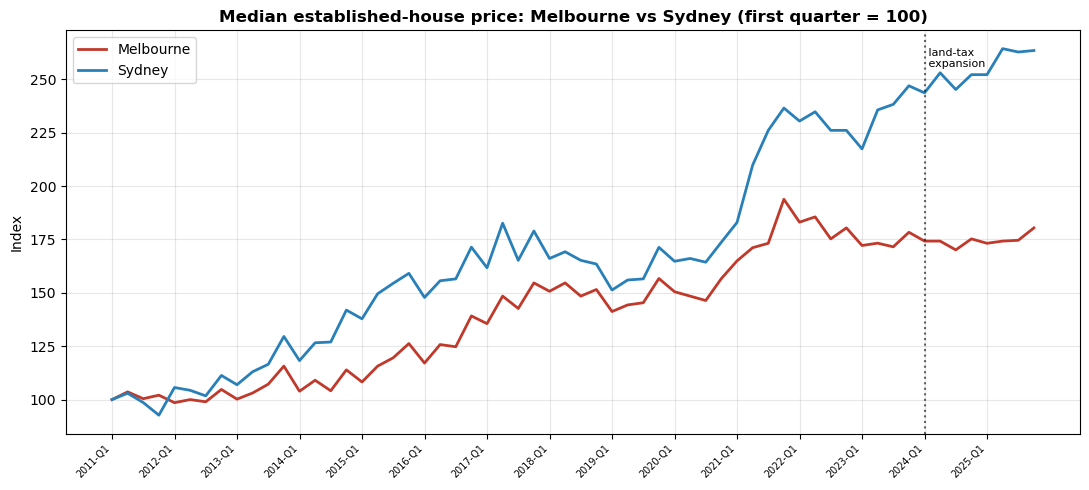

Chart saved -> exports/analysis/nb_melbourne_vs_sydney.png


In [21]:
import numpy as np

conn = get_conn()
# Cash rate -> quarterly average
cr = pd.read_sql_query("SELECT period, rate_pct FROM cash_rate", conn)
cr["q"] = (pd.PeriodIndex(pd.to_datetime(cr["period"] + "-01"), freq="Q")
             .astype(str).str.replace("Q", "-Q"))
cash_q = cr.groupby("q")["rate_pct"].mean()

# Capital-city median house prices -> wide panel
cap = pd.read_sql_query(
    "SELECT period, region, value FROM capital_prices "
    "WHERE measure='median_house' AND region LIKE 'Greater%'", conn)
conn.close()
piv = cap.pivot_table(index="period", columns="region", values="value").sort_index()
MEL, SYD = "Greater Melbourne", "Greater Sydney"

# --- Rate sensitivity: Melbourne house-price level vs cash-rate level ---
lp = pd.concat([np.log(piv[MEL]).rename("lp"), cash_q.rename("cash")], axis=1).dropna()
print(f"corr(log Melbourne house price, cash-rate level) = {lp['lp'].corr(lp['cash']):+.3f}")
print(f"Cash rate now {cash_q.iloc[-1]:.2f}%   (2022-Q1 trough-era {cash_q.get('2022-Q1', float('nan')):.2f}%)")

# --- Difference-in-differences: VIC-specific policy vs Sydney control ---
def did(ev, pre=6, post=6):
    sub = piv[[MEL, SYD]].dropna(); P = list(sub.index)
    if ev not in P:
        return float("nan")
    i = P.index(ev); a = P[max(0, i-pre):i]; b = P[i:i+post]
    g = lambda c, q: (sub.loc[q[-1], c] / sub.loc[q[0], c] - 1) * 100
    return (g(MEL, b) - g(MEL, a)) - (g(SYD, b) - g(SYD, a))

print(f"\n2024 VIC land-tax DiD (Melbourne vs Sydney): {did('2024-Q1'):+.1f} pts")
print(f"Placebo 2019-Q2: {did('2019-Q2'):+.1f} pts   |   Placebo 2021-Q3: {did('2021-Q3'):+.1f} pts")
print("--> |placebos| >> |2024 effect|  => no land-tax price effect distinguishable from city-cycle noise")

# --- Chart: Melbourne vs Sydney indexed ---
fig, ax = plt.subplots(figsize=(11, 5))
for c, col in [(MEL, "#c0392b"), (SYD, "#2980b9")]:
    s = piv[c].dropna(); s = s / s.iloc[0] * 100
    ax.plot(range(len(s)), s.values, label=c.replace("Greater ", ""), lw=2, color=col)
if "2024-Q1" in piv.index:
    ax.axvline(list(piv.index).index("2024-Q1"), ls=":", c="black", alpha=.6)
    ax.text(list(piv.index).index("2024-Q1"), ax.get_ylim()[1]*0.97, " land-tax\n expansion", fontsize=8, va="top")
ax.set_xticks(range(0, len(piv.index), 4))
ax.set_xticklabels(piv.index[::4], rotation=45, ha="right", fontsize=7)
ax.set_title("Median established-house price: Melbourne vs Sydney (first quarter = 100)", fontweight="bold")
ax.set_ylabel("Index"); ax.legend(); ax.grid(alpha=.3)
import os; os.makedirs("exports/analysis", exist_ok=True)
plt.tight_layout(); plt.savefig("exports/analysis/nb_melbourne_vs_sydney.png", dpi=140); plt.show()
print("Chart saved -> exports/analysis/nb_melbourne_vs_sydney.png")
